In [1]:
import pandas as pd
from db_connection import conn, cursor

Database connected successfully


In [2]:
query = """
SELECT
    w.location_id,
    l.location,
    w.[date],
    w.rainfall,
    w.temperature,
    w.humidity,
    w.pressure,
    w.wind_speed,
    r.river_discharge,
    CASE 
        WHEN lb.date IS NOT NULL THEN 1
        ELSE 0
    END AS flood

FROM weather_data w
JOIN river_data r ON w.location_id = r.location_id
AND CAST(w.[date] AS DATE) = CAST(r.[date] AS DATE)

JOIN location_data l ON w.location_id = l.location_id

LEFT JOIN label_data lb 
ON w.date = lb.date
AND w.location_id = lb.location_id
"""

In [3]:
df = pd.read_sql(query,conn)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_20688\785092515.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,conn)


# EDA

In [4]:
df.head()

,location_id,location,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,flood
0,1,Hue,2001-07-01,0.0,28.600000,68.0,1000.400024,24.799999,0.53,0
1,1,Hue,2001-07-02,0.2,29.100000,70.0,998.700012,20.900000,0.44,0
2,1,Hue,2001-07-03,1.8,28.600000,79.0,999.599976,6.900000,0.42,0
3,1,Hue,2001-07-04,13.8,27.799999,85.0,999.900024,11.500000,0.44,0
4,1,Hue,2001-07-05,0.0,28.799999,74.0,997.500000,25.200001,0.41,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18286 entries, 0 to 18285
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   location_id      18286 non-null  int64  
 1   location         18286 non-null  str    
 2   date             18286 non-null  object 
 3   rainfall         18286 non-null  float64
 4   temperature      18286 non-null  float64
 5   humidity         18286 non-null  float64
 6   pressure         18286 non-null  float64
 7   wind_speed       18286 non-null  float64
 8   river_discharge  18286 non-null  float64
 9   flood            18286 non-null  int64  
dtypes: float64(6), int64(2), object(1), str(1)
memory usage: 1.4+ MB


In [7]:
df['date'] = pd.to_datetime(df['date'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18286 entries, 0 to 18285
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype        
---  ------           --------------  -----        
 0   location_id      18286 non-null  int64        
 1   location         18286 non-null  str          
 2   date             18286 non-null  datetime64[s]
 3   rainfall         18286 non-null  float64      
 4   temperature      18286 non-null  float64      
 5   humidity         18286 non-null  float64      
 6   pressure         18286 non-null  float64      
 7   wind_speed       18286 non-null  float64      
 8   river_discharge  18286 non-null  float64      
 9   flood            18286 non-null  int64        
dtypes: datetime64[s](1), float64(6), int64(2), str(1)
memory usage: 1.4 MB


In [9]:
df = df.drop(columns = ['location'])
df.head()

,location_id,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,flood
0,1,2001-07-01,0.0,28.600000,68.0,1000.400024,24.799999,0.53,0
1,1,2001-07-02,0.2,29.100000,70.0,998.700012,20.900000,0.44,0
2,1,2001-07-03,1.8,28.600000,79.0,999.599976,6.900000,0.42,0
3,1,2001-07-04,13.8,27.799999,85.0,999.900024,11.500000,0.44,0
4,1,2001-07-05,0.0,28.799999,74.0,997.500000,25.200001,0.41,0


In [10]:
df.isnull().sum()

location_id        0
date               0
rainfall           0
temperature        0
humidity           0
pressure           0
wind_speed         0
river_discharge    0
flood              0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.duplicated(subset = ['location_id','date']).sum()

np.int64(0)

In [13]:
df.describe()

,location_id,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,flood
count,18286.000000,18286,18286.000000,18286.000000,18286.000000,18286.000000,18286.000000,18286.000000,18286.000000
mean,1.500000,2014-01-05 00:00:00,7.876736,25.758537,83.012851,1009.344411,14.339380,23.587589,0.175708
min,1.000000,2001-07-01 00:00:00,0.000000,14.100000,45.000000,984.400024,4.200000,0.080000,0.000000
25%,1.000000,2007-10-03 06:00:00,0.200000,23.299999,80.000000,1005.299988,11.300000,0.670000,0.000000
50%,1.500000,2014-01-05 00:00:00,2.200000,26.000000,84.000000,1009.000000,13.600000,6.530000,0.000000
75%,2.000000,2020-04-08 18:00:00,8.400000,28.400000,88.000000,1013.299988,16.600000,14.850000,0.000000
max,2.000000,2026-07-12 00:00:00,398.799988,34.599998,97.000000,1028.400024,64.599998,1569.359985,1.000000
std,0.500014,NaN,16.872527,3.285306,7.064243,5.201703,4.613390,68.787972,0.380582


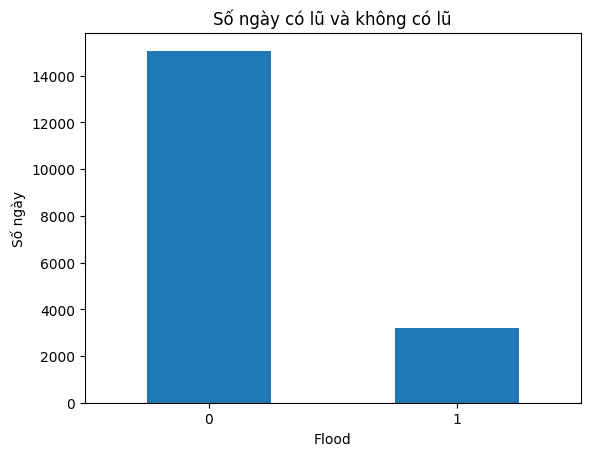

In [18]:
import matplotlib.pyplot as plt

df["flood"].value_counts().plot(kind="bar")

plt.title("Số ngày có lũ và không có lũ")
plt.xlabel("Flood")
plt.ylabel("Số ngày")
plt.xticks(rotation=0)
plt.show()

In [19]:
df["flood"].value_counts(normalize=True) * 100

flood
0    82.429181
1    17.570819
Name: proportion, dtype: float64

- Dữ liệu bị lệch nhãn, nhưng chưa đến mức quá nghiêm trọng.
- Model có thể có xu hướng dự đoán nhiều ngày là không lũ vì lớp 0 nhiều hơn lớp 1.
- Vì vậy sau này:
- Không chỉ dùng accuracy
- Cần xem recall, precision, F1-score
- Có thể dùng class_weight="balanced"

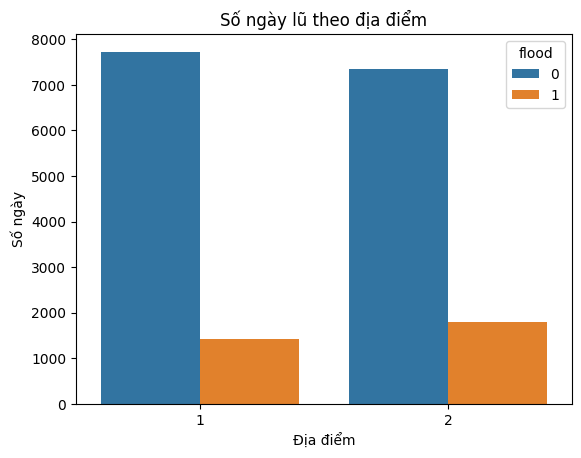

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    data=df,
    x="location_id",
    hue="flood"
)

plt.title("Số ngày lũ theo địa điểm")
plt.xlabel("Địa điểm")
plt.ylabel("Số ngày")
plt.show()

- Hai khu vực có mức độ lũ giống nhau
- location có thể là feature quan trọng 
- Dữ liệu không bị lệch quá nhiều về một khu vực 

- Kết luận hiện tại: nên giữ location_id khi train vì nguy cơ lũ giữa Huế và Quảng Nam không hoàn toàn giống nhau.

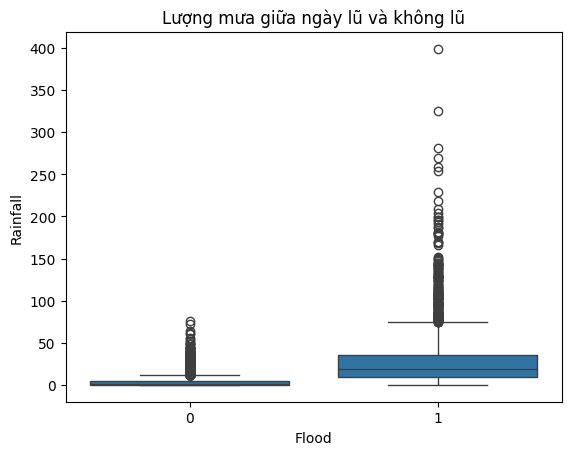

In [24]:
sns.boxplot(
    data=df,
    x="flood",
    y="rainfall"
)

plt.title("Lượng mưa giữa ngày lũ và không lũ")
plt.xlabel("Flood")
plt.ylabel("Rainfall")
plt.show()

- Nhóm flood = 1 có lượng mưa cao rõ rệt so với nhóm flood = 0
- rainfall là 1 feature quan trọng
- Những chấm rất cao không nhất thiết là dữ liệu lỗi. Trong bài toán lũ, mưa cực lớn chính là trường hợp quan trọng
- Không nên xóa outlier rainfall một cách máy móc.

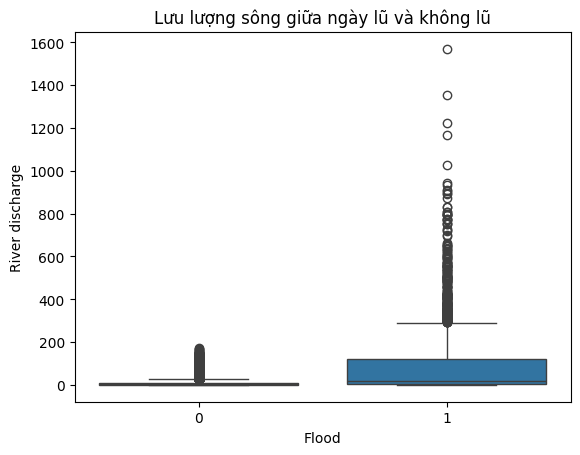

In [25]:
sns.boxplot(
    data=df,
    x="flood",
    y="river_discharge"
)

plt.title("Lưu lượng sông giữa ngày lũ và không lũ")
plt.xlabel("Flood")
plt.ylabel("River discharge")
plt.show()

- river_discharge cũng là feature quan trọng

In [26]:
df.groupby("flood")[
    ["rainfall", "river_discharge"]
].mean()

,rainfall,river_discharge
flood,,
0,3.647024,9.793397
1,27.719390,88.299651


* Ngày lũ có lượng mưa trung bình cao hơn
* Ngày lũ có lưu lượng sông trung bình cao hơn
* Hai biến này có khả năng quan trọng cho model

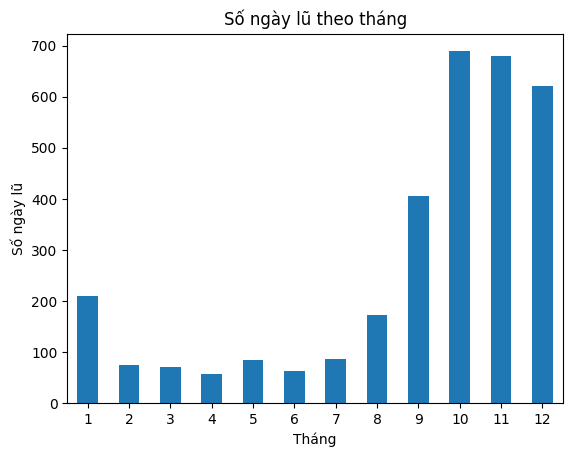

In [28]:
df["month"] = df["date"].dt.month

flood_by_month = (
    df[df["flood"] == 1]
    .groupby("month")
    .size()
)

flood_by_month.plot(kind="bar")

plt.title("Số ngày lũ theo tháng")
plt.xlabel("Tháng")
plt.ylabel("Số ngày lũ")
plt.xticks(rotation=0)
plt.show()

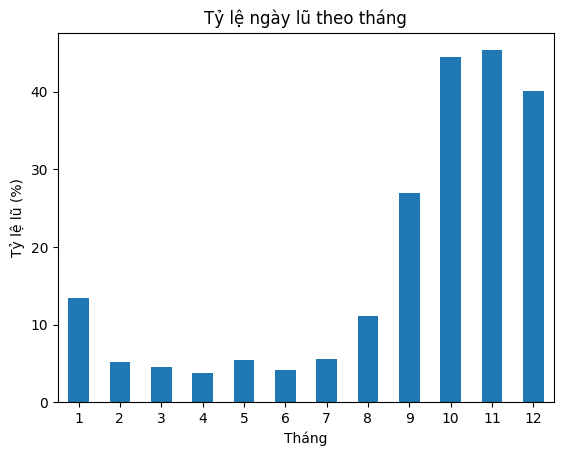

In [29]:
flood_rate_by_month = (
    df.groupby("month")["flood"]
    .mean()
    .mul(100)
)

flood_rate_by_month.plot(kind="bar")

plt.title("Tỷ lệ ngày lũ theo tháng")
plt.xlabel("Tháng")
plt.ylabel("Tỷ lệ lũ (%)")
plt.xticks(rotation=0)
plt.show()

# CREATE FEATURES|

### Mưa tích lũy 3 ngày

In [37]:
df["rainfall_3d"] = (
    df.groupby("location_id")["rainfall"]
    .transform(
        lambda x: x.rolling(
            window=3,
            min_periods=3
        ).sum()
    )
)

### Mưa tích lũy 7 ngày 

In [34]:
df["rainfall_7d"] = (
    df.groupby("location_id")["rainfall"]
    .transform(
        lambda x: x.rolling(
            window=7,
            min_periods=7
        ).sum()
    )
)

df.head()

,location_id,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,flood,month,rainfall_3d,rainfall_7d
0,1,2001-07-01,0.0,28.600000,68.0,1000.400024,24.799999,0.53,0,7,NaN,NaN
1,1,2001-07-02,0.2,29.100000,70.0,998.700012,20.900000,0.44,0,7,NaN,NaN
2,1,2001-07-03,1.8,28.600000,79.0,999.599976,6.900000,0.42,0,7,2.0,NaN
3,1,2001-07-04,13.8,27.799999,85.0,999.900024,11.500000,0.44,0,7,15.8,NaN
4,1,2001-07-05,0.0,28.799999,74.0,997.500000,25.200001,0.41,0,7,15.6,NaN


### Mức thay đổi lưu lượng sông:
* Giá trị dương: nước sông đang tăng
* Giá trị âm: nước sông đang giảm
* Giá trị lớn: nước đang tăng nhanh

In [36]:
df["discharge_change_1d"] = (
    df.groupby("location_id")["river_discharge"]
    .diff(1)
)

df.head()

,location_id,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,flood,month,rainfall_3d,rainfall_7d,discharge_change_1d
0,1,2001-07-01,0.0,28.600000,68.0,1000.400024,24.799999,0.53,0,7,NaN,NaN,NaN
1,1,2001-07-02,0.2,29.100000,70.0,998.700012,20.900000,0.44,0,7,NaN,NaN,-0.09
2,1,2001-07-03,1.8,28.600000,79.0,999.599976,6.900000,0.42,0,7,2.0,NaN,-0.02
3,1,2001-07-04,13.8,27.799999,85.0,999.900024,11.500000,0.44,0,7,15.8,NaN,0.02
4,1,2001-07-05,0.0,28.799999,74.0,997.500000,25.200001,0.41,0,7,15.6,NaN,-0.03


In [ ]:
# xóa các dòng null ở đầu 
df = df.dropna().reset_index(drop=True)

### tạo 3 target ngày cần đoán

In [41]:
df["target_d1"] = (
    df.groupby("location_id")["flood"]
    .shift(-1)
)

df["target_d2"] = (
    df.groupby("location_id")["flood"]
    .shift(-2)
)

df["target_d3"] = (
    df.groupby("location_id")["flood"]
    .shift(-3)
)

df.tail()

,location_id,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,flood,month,rainfall_3d,rainfall_7d,discharge_change_1d,target_d1,target_d2,target_d3
18269,2,2026-07-08,1.8,30.500000,66.0,1003.700012,20.4,9.02,0,7,5.400000,26.2,0.25,0.0,0.0,0.0
18270,2,2026-07-09,3.3,31.000000,64.0,1003.599976,24.0,9.84,0,7,7.000000,27.4,0.82,0.0,0.0,0.0
18271,2,2026-07-10,11.1,28.700001,80.0,1002.900024,14.9,7.73,0,7,16.200000,26.5,-2.11,0.0,0.0,NaN
18272,2,2026-07-11,1.2,31.400000,58.0,1000.000000,24.6,7.69,0,7,15.600000,21.1,-0.04,0.0,NaN,NaN
18273,2,2026-07-12,7.4,31.100000,63.0,1000.000000,16.6,7.71,0,7,19.700001,28.4,0.02,NaN,NaN,NaN


In [43]:
df = df.dropna(
    subset=["target_d1", "target_d2", "target_d3"]
).reset_index(drop=True)

df.tail()

,location_id,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,flood,month,rainfall_3d,rainfall_7d,discharge_change_1d,target_d1,target_d2,target_d3
18263,2,2026-07-05,0.1,29.799999,73.0,1005.599976,12.7,8.93,0,7,18.7,47.4,-0.71,0.0,0.0,0.0
18264,2,2026-07-06,1.7,30.200001,70.0,1005.700012,10.8,9.26,0,7,8.4,34.8,0.33,0.0,0.0,0.0
18265,2,2026-07-07,1.9,29.000000,75.0,1004.799988,9.2,8.77,0,7,3.7,35.0,-0.49,0.0,0.0,0.0
18266,2,2026-07-08,1.8,30.500000,66.0,1003.700012,20.4,9.02,0,7,5.4,26.2,0.25,0.0,0.0,0.0
18267,2,2026-07-09,3.3,31.000000,64.0,1003.599976,24.0,9.84,0,7,7.0,27.4,0.82,0.0,0.0,0.0


In [44]:
target_cols = [
    'target_d1',
    'target_d2',
    'target_d3'
]

df[target_cols] = df[target_cols].astype('int64')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18268 entries, 0 to 18267
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype        
---  ------               --------------  -----        
 0   location_id          18268 non-null  int64        
 1   date                 18268 non-null  datetime64[s]
 2   rainfall             18268 non-null  float64      
 3   temperature          18268 non-null  float64      
 4   humidity             18268 non-null  float64      
 5   pressure             18268 non-null  float64      
 6   wind_speed           18268 non-null  float64      
 7   river_discharge      18268 non-null  float64      
 8   flood                18268 non-null  int64        
 9   month                18268 non-null  int32        
 10  rainfall_3d          18268 non-null  float64      
 11  rainfall_7d          18268 non-null  float64      
 12  discharge_change_1d  18268 non-null  float64      
 13  target_d1            18268 non-null  int64        
 14  t

In [46]:
df.head()

,location_id,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,flood,month,rainfall_3d,rainfall_7d,discharge_change_1d,target_d1,target_d2,target_d3
0,1,2001-07-07,0.5,30.200001,68.0,998.400024,23.1,0.36,0,7,0.5,16.3,-0.01,0,0,0
1,1,2001-07-08,38.0,28.400000,82.0,1003.099976,6.2,0.70,0,7,38.5,54.3,0.34,0,0,0
2,1,2001-07-09,6.7,28.000000,80.0,1006.400024,8.1,1.28,0,7,45.2,60.8,0.58,0,0,0
3,1,2001-07-10,0.2,28.200001,79.0,1006.200012,9.2,0.92,0,7,44.9,59.2,-0.36,0,0,0
4,1,2001-07-11,0.8,28.600000,80.0,1004.700012,9.1,0.58,0,7,7.7,46.2,-0.34,0,0,0


In [47]:
df.to_csv("../data/train/train_data.csv",index = False)
print("done")

done
